In [1]:
%pip install tensorflow numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------- ----------- 1.3/1.8 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 8.1 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.2
    Uninstalling pip-26.2:
      Successfully uninstalled pip-26.2
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist, mnist

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.20.0


In [5]:
print("--- Loading Fashion MNIST Dataset ---")

(x_train_fnn, y_train_fnn), (x_test_fnn, y_test_fnn) = fashion_mnist.load_data()

print("Training data shape:", x_train_fnn.shape)
print("Testing data shape:", x_test_fnn.shape)

--- Loading Fashion MNIST Dataset ---
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 33s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


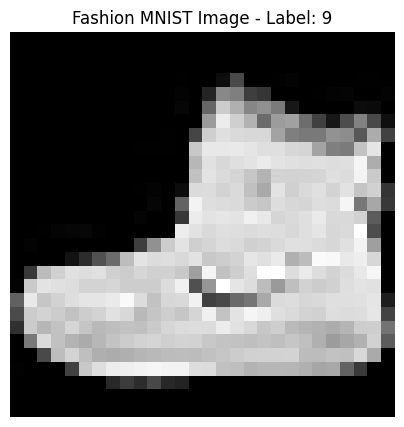

In [6]:
plt.figure(figsize=(5, 5))

plt.imshow(x_train_fnn[0], cmap='gray')

plt.title(f"Fashion MNIST Image - Label: {y_train_fnn[0]}")
plt.axis('off')

plt.show()

In [7]:
x_train_fnn_flat = x_train_fnn.reshape(-1, 28 * 28)
x_test_fnn_flat = x_test_fnn.reshape(-1, 28 * 28)

print("Flattened training data shape:", x_train_fnn_flat.shape)
print("Flattened testing data shape:", x_test_fnn_flat.shape)

Flattened training data shape: (60000, 784)
Flattened testing data shape: (10000, 784)


In [8]:
x_train_fnn_norm = x_train_fnn_flat / 255.0
x_test_fnn_norm = x_test_fnn_flat / 255.0

print("Minimum pixel value:", x_train_fnn_norm.min())
print("Maximum pixel value:", x_train_fnn_norm.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [9]:
model_fnn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("--- FNN Model Created ---")

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- FNN Model Created ---


In [10]:
model_fnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- FNN Model Compiled ---")

--- FNN Model Compiled ---


In [11]:
model_fnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print("--- Training FNN Model ---")

history_fnn = model_fnn.fit(
    x_train_fnn_norm,
    y_train_fnn,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

--- Training FNN Model ---
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8072 - loss: 0.5391 - val_accuracy: 0.8537 - val_loss: 0.3957
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8507 - loss: 0.4096 - val_accuracy: 0.8620 - val_loss: 0.3727
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8612 - loss: 0.3744 - val_accuracy: 0.8727 - val_loss: 0.3457
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8686 - loss: 0.3535 - val_accuracy: 0.8747 - val_loss: 0.3442
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8750 - loss: 0.3360 - val_accuracy: 0.8823 - val_loss: 0.3236


In [13]:
print("--- Evaluating FNN Model ---")

loss_fnn, accuracy_fnn = model_fnn.evaluate(
    x_test_fnn_norm,
    y_test_fnn,
    verbose=0
)

print(f"FNN Test Loss: {loss_fnn:.4f}")
print(f"FNN Test Accuracy: {accuracy_fnn:.4f}")

--- Evaluating FNN Model ---
FNN Test Loss: 0.3523
FNN Test Accuracy: 0.8729


In [14]:
y_pred_fnn_prob = model_fnn.predict(
    x_test_fnn_norm,
    verbose=0
)

y_pred_fnn = np.argmax(
    y_pred_fnn_prob,
    axis=1
)

print("First 10 Actual Labels:")
print(y_test_fnn[:10])

print("\nFirst 10 Predicted Labels:")
print(y_pred_fnn[:10])

First 10 Actual Labels:
[9 2 1 1 6 1 4 6 5 7]

First 10 Predicted Labels:
[9 2 1 1 6 1 4 6 5 7]


In [15]:
print("--- FNN Classification Report ---")

print(
    classification_report(
        y_test_fnn,
        y_pred_fnn
    )
)

--- FNN Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1000
           1       0.98      0.97      0.97      1000
           2       0.78      0.77      0.78      1000
           3       0.86      0.89      0.88      1000
           4       0.75      0.82      0.78      1000
           5       0.95      0.97      0.96      1000
           6       0.73      0.59      0.65      1000
           7       0.95      0.94      0.94      1000
           8       0.96      0.97      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



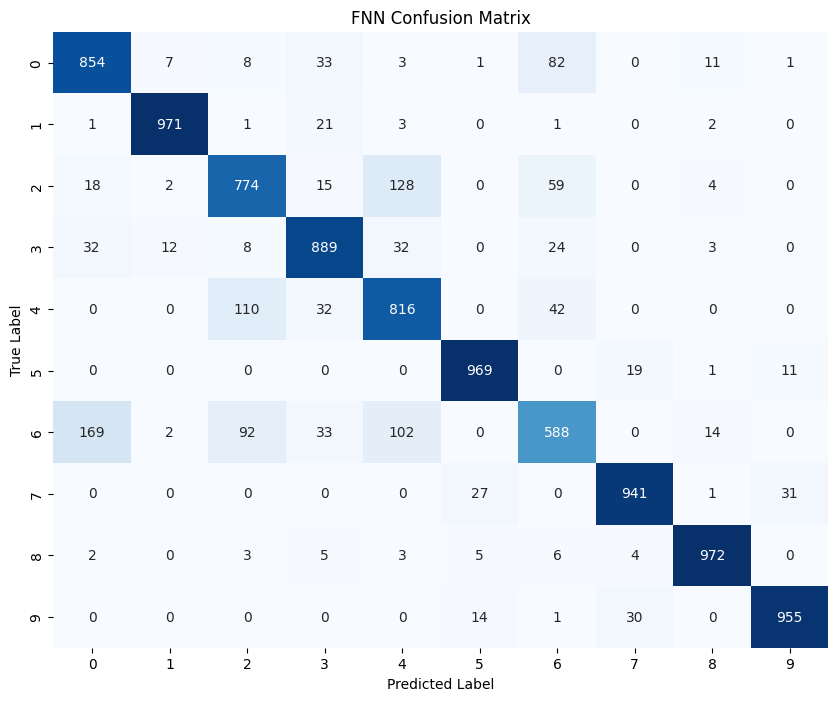

In [16]:
cm_fnn = confusion_matrix(
    y_test_fnn,
    y_pred_fnn
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_fnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('FNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

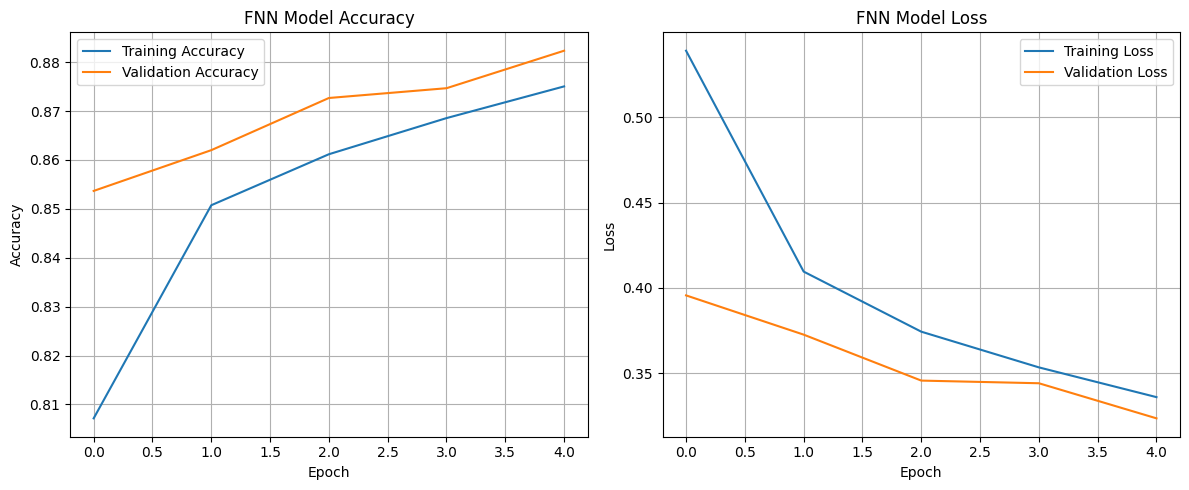

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_fnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_fnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('FNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(
    history_fnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_fnn.history['val_loss'],
    label='Validation Loss'
)

plt.title('FNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
print("--- Loading MNIST Dataset for CNN ---")

(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = mnist.load_data()

print("Training data shape:", x_train_cnn.shape)
print("Testing data shape:", x_test_cnn.shape)

--- Loading MNIST Dataset for CNN ---
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


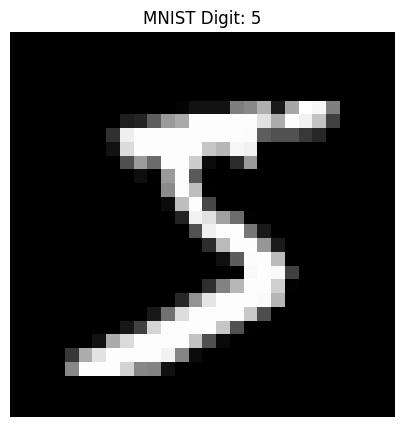

In [19]:
plt.figure(figsize=(5, 5))

plt.imshow(x_train_cnn[0], cmap='gray')

plt.title(f"MNIST Digit: {y_train_cnn[0]}")
plt.axis('off')

plt.show()

In [20]:
x_train_cnn = x_train_cnn.reshape(
    x_train_cnn.shape[0],
    28,
    28,
    1
)

x_test_cnn = x_test_cnn.reshape(
    x_test_cnn.shape[0],
    28,
    28,
    1
)

print("Reshaped training data:", x_train_cnn.shape)
print("Reshaped testing data:", x_test_cnn.shape)

Reshaped training data: (60000, 28, 28, 1)
Reshaped testing data: (10000, 28, 28, 1)


In [21]:
x_train_cnn = x_train_cnn.astype('float32') / 255.0
x_test_cnn = x_test_cnn.astype('float32') / 255.0

print("Minimum pixel value:", x_train_cnn.min())
print("Maximum pixel value:", x_train_cnn.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [22]:
num_classes_cnn = 10

print("Number of classes:", num_classes_cnn)

Number of classes: 10


In [23]:
model_cnn = keras.Sequential([
    
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(
        128,
        activation='relu'
    ),
    
    layers.Dropout(0.5),
    
    layers.Dense(
        num_classes_cnn,
        activation='softmax'
    )
])

print("--- CNN Model Created ---")

--- CNN Model Created ---


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- CNN Model Compiled ---")

--- CNN Model Compiled ---


In [25]:
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
print("--- Training CNN Model ---")

history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train_cnn,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

--- Training CNN Model ---
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9322 - loss: 0.2237 - val_accuracy: 0.9848 - val_loss: 0.0538
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9765 - loss: 0.0812 - val_accuracy: 0.9877 - val_loss: 0.0490
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9816 - loss: 0.0618 - val_accuracy: 0.9883 - val_loss: 0.0355
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9854 - loss: 0.0492 - val_accuracy: 0.9915 - val_loss: 0.0356
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9877 - loss: 0.0412 - val_accuracy: 0.9915 - val_loss: 0.0312


In [27]:
y_pred_cnn_prob = model_cnn.predict(
    x_test_cnn,
    verbose=0
)

y_pred_cnn = np.argmax(
    y_pred_cnn_prob,
    axis=1
)

print("First 10 Actual Labels:")
print(y_test_cnn[:10])

print("\nFirst 10 Predicted Labels:")
print(y_pred_cnn[:10])

First 10 Actual Labels:
[7 2 1 0 4 1 4 9 5 9]

First 10 Predicted Labels:
[7 2 1 0 4 1 4 9 5 9]


In [30]:
print("--- CNN Classification Report ---")

print(
    classification_report(
        y_test_cnn,
        y_pred_cnn
    )
)

--- CNN Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



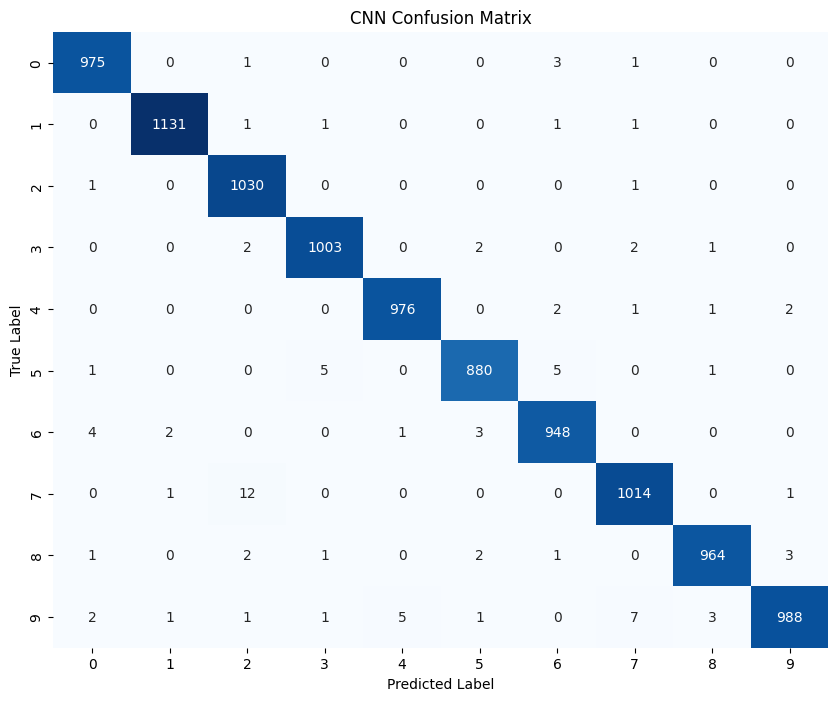

In [31]:
cm_cnn = confusion_matrix(
    y_test_cnn,
    y_pred_cnn
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

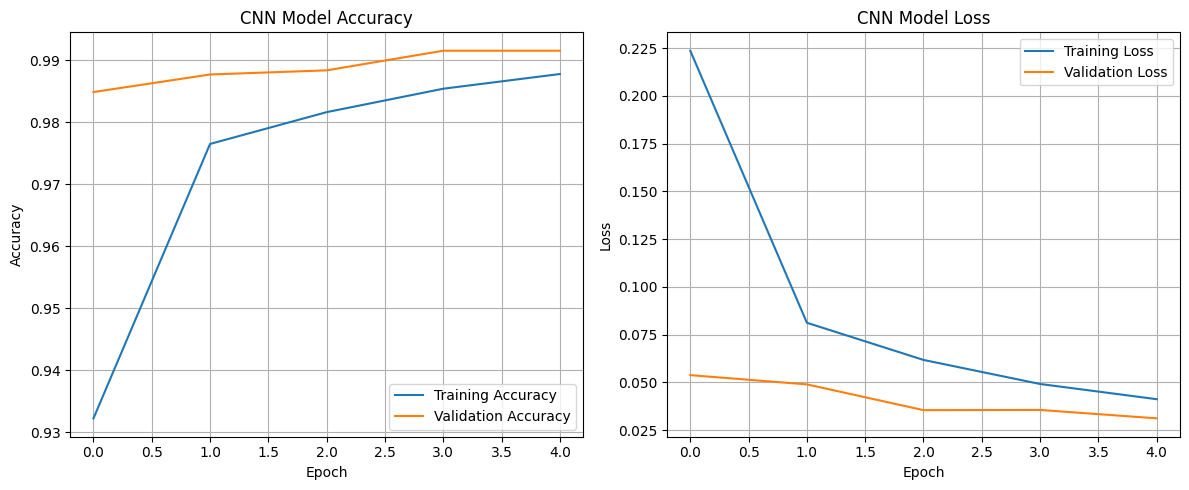

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

--- Sample CNN Predictions ---


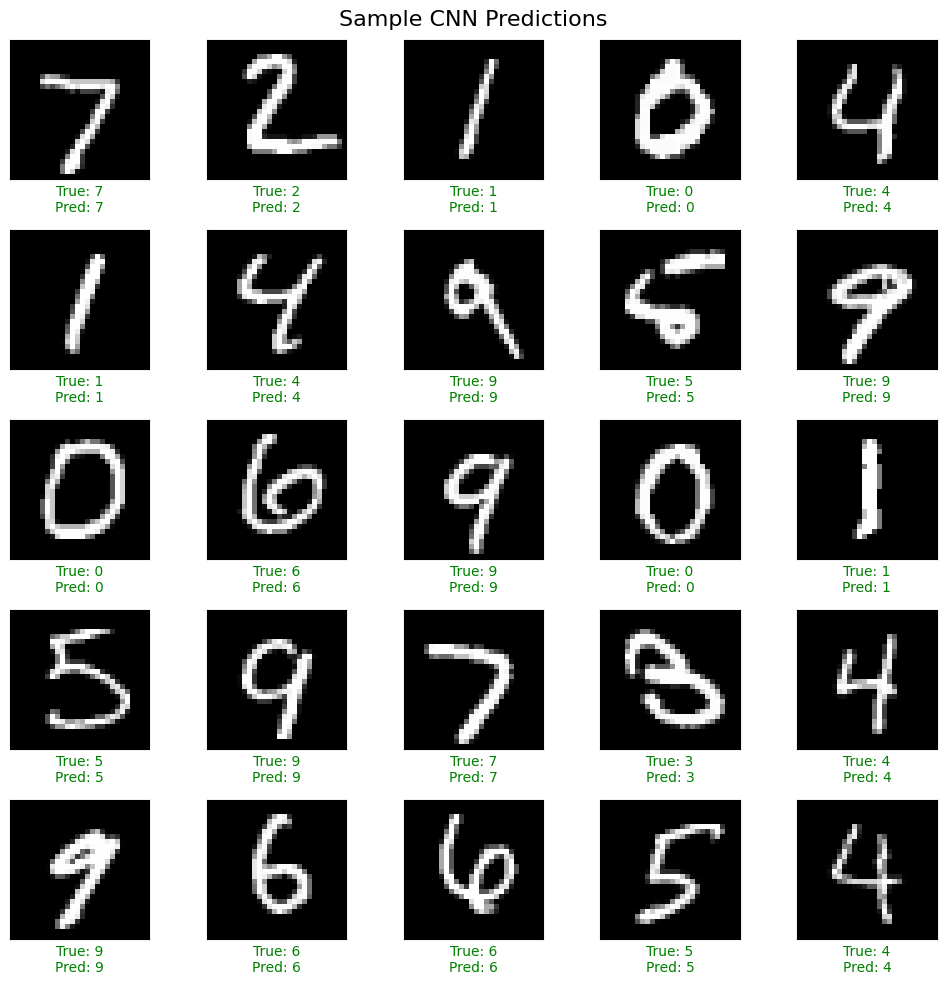

In [33]:
print("--- Sample CNN Predictions ---")

class_names_mnist = [
    '0', '1', '2', '3', '4',
    '5', '6', '7', '8', '9'
]

plt.figure(figsize=(10, 10))

for i in range(25):
    
    plt.subplot(5, 5, i + 1)
    
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    plt.imshow(
        x_test_cnn[i].reshape(28, 28),
        cmap='gray'
    )
    
    true_label = y_test_cnn[i]
    predicted_label = y_pred_cnn[i]
    
    if true_label == predicted_label:
        color = 'green'
    else:
        color = 'red'
    
    plt.xlabel(
        f"True: {class_names_mnist[true_label]}\n"
        f"Pred: {class_names_mnist[predicted_label]}",
        color=color
    )

plt.suptitle(
    "Sample CNN Predictions",
    fontsize=16
)

plt.tight_layout()

plt.show()